# `In the name of Allah, the most Gracious, the most Merciful`

# GRADIENT DESCENT 
---

## TABLE OF CONTENTS

1. Key Variables & Symbols

2. Complete Code Implementation

3. The Cost Function Explained

4. The Gradient Explained

5. The Update Rules Explained

6. Running Gradient Descent

7. Common Scenarios & Questions

8. Memory Aids & Cheat Sheets

---

## KEY VARIABLES & SYMBOLS

| Symbol | Name | What it means | Example Value |
|--------|------|---------------|---------------|
| `x` | Feature | Input data (house sizes) | `[1.0, 2.0]` |
| `y` | Target | Output we want (prices) | `[300.0, 500.0]` |
| `m` | Number of examples | How many data points | `2` |
| `w` | Weight/Slope | Steepness of the line | `200` |
| `b` | Bias/Intercept | Where line crosses y-axis | `100` |
| `α` (alpha) | Learning rate | How big each step is | `0.01` |
| `J(w,b)` | Cost | Total error of predictions | `0.0001` |
| `dj_dw` | Gradient for w | How cost changes with w | `-0.001` |
| `dj_db` | Gradient for b | How cost changes with b | `-0.001` |

---

## THE COST FUNCTION EXPLAINED

### Purpose: Measures how wrong our predictions are

**The Formula:**
$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

**Where:**
$$f_{w,b}(x) = wx + b$$

**Step-by-Step Breakdown:**

1. **For each data point (i):**
   - Make a prediction: `f_wb = w * x[i] + b`
   - Find the error: `error = f_wb - y[i]`
   - Square the error: `error²` (makes negatives positive)

2. **Sum all errors:** `Σ error²`

3. **Average:** Divide by `2m` (m = number of examples)

**Cost Values Guide:**

| Cost Value | Meaning | Status |
|------------|---------|--------|
| > 100,000 | Very wrong | Bad |
| 1,000 - 10,000 | Somewhat wrong | Improving |
| 1 - 100 | Close to right | Good |
| < 0.01 | Almost perfect | Excellent |
| 0 | Perfect match | Ideal |

---

## THE GRADIENT EXPLAINED

### Purpose: Tells us which direction to move to reduce cost

**The Formulas:**
$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}$$

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})$$

**What Each Part Means:**

| Part | What it represents |
|------|-------------------|
| `(f_wb - y)` | How wrong our prediction is |
| `x` | How much w affects this prediction |
| `1/m` | Average over all examples |

**Gradient Interpretation Guide:**

| Gradient Sign | What it means | What to do |
|---------------|---------------|------------|
| **Positive (+)** | Increasing parameter INCREASES cost | **Decrease** the parameter |
| **Negative (-)** | Increasing parameter DECREASES cost | **Increase** the parameter |
| **Zero (0)** | At minimum point | Keep parameter **same** |

---

## THE UPDATE RULES EXPLAINED

### Purpose: Takes us one step closer to the minimum

**The Rules:**
$$w = w - \alpha \frac{\partial J(w,b)}{\partial w}$$

$$b = b - \alpha \frac{\partial J(w,b)}{\partial b}$$

**Why Subtract?**

| Scenario | What happens | Example |
|----------|--------------|---------|
| Gradient positive | cost increases when w increases → decrease w | `w = w - α×(+5) = w - something` |
| Gradient negative | cost decreases when w increases → increase w | `w = w - α×(-5) = w + something` |
| Gradient zero | at minimum → don't change | `w = w - α×0 = w` |

**Learning Rate (α) Guide:**

| α value | Effect | Result |
|---------|--------|--------|
| Too small (0.0001) | Tiny steps | Slow convergence 🐢 |
| Just right (0.01) | Good steps | Efficient convergence ✅ |
| Too big (0.8) | Huge leaps | Might overshoot/diverge 💥 |

---

## COMMON SCENARIOS & QUESTIONS

### Q1: If dj_dw = 5 and alpha = 0.01, does w increase or decrease?

**Answer:** **DECREASES**

```python
w = w - 0.01 × 5
w = w - 0.05  # SUBTRACTING, so w goes down
```

### Q2: If dj_db = -3 and alpha = 0.01, does b increase or decrease?

**Answer:** **INCREASES**

```python
b = b - 0.01 × (-3)
b = b + 0.03  # ADDING, so b goes up
```

### Q3: What if cost is INCREASING after each iteration?

**Answer:** **Learning rate (α) is too large!**

**Fix:** Decrease α (try 0.001 or 0.0001)

### Q4: What if cost is DECREASING very slowly?

**Answer:** **Learning rate (α) is too small!**

**Fix:** Increase α (try 0.01 or 0.05)

### Q5: What happens when gradient = 0?

**Answer:** **We've reached the minimum!**

```python
w = w - α × 0 = w  # No change
b = b - α × 0 = b  # No change
```

### Q6: Why do we update w and b simultaneously?

**Answer:** To use the correct gradients!

**Bad (sequential):**
```python
w = w - alpha * dj_dw  # w changes
b = b - alpha * dj_db  # Uses new w! (wrong)
```

**Good (simultaneous):**
```python
dj_dw, dj_db = compute_gradient(x, y, w, b)  # Both from old values
w = w - alpha * dj_dw  # Update both
b = b - alpha * dj_db  # Using old gradients (correct)
```

---

## MEMORY AIDS & CHEAT SHEETS

### A. The Gradient Sign Rule

**Memorize this rhyme:**
```
Gradient positive? Go down.
Gradient negative? Turn it around.
Gradient zero? You're on the ground!
```

| Gradient | Direction | Action |
|----------|-----------|--------|
| + | Uphill | Go DOWN ↓ |
| - | Downhill | Go UP ↑ |
| 0 | Flat | STOP ➡ |

### B. The "Hiking" Analogy

| Concept | Hiking | Machine Learning |
|---------|--------|------------------|
| Goal | Reach valley bottom | Minimize cost |
| Position | Where you stand | Current w,b |
| Downhill direction | Which way to walk | Negative gradient |
| Step size | How far to walk | Learning rate (α) |
| Altitude | Height above valley | Cost value |
| Trip diary | Recording your path | J_history, p_history |

### C. Quick Reference Code

```python
# COST FUNCTION
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i])**2
    return cost / (2 * m)

# GRADIENT FUNCTION
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw, dj_db = 0, 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])
    return dj_dw / m, dj_db / m

# UPDATE RULES
dj_dw, dj_db = compute_gradient(x, y, w, b)
w = w - alpha * dj_dw
b = b - alpha * dj_db

# STOPPING CONDITIONS
# 1. Maximum iterations reached
# 2. Gradient ≈ 0 (converged)
# 3. Cost stops decreasing
```

### D. Signs & Their Meanings

| What you see | What it means |
|--------------|---------------|
| `dj_dw > 0` | Need to DECREASE w |
| `dj_dw < 0` | Need to INCREASE w |
| `dj_dw = 0` | w is perfect! |
| `dj_db > 0` | Need to DECREASE b |
| `dj_db < 0` | Need to INCREASE b |
| `dj_db = 0` | b is perfect! |

### E. Common Mistakes to Avoid

**Mistake 1:** Updating w then using new w for b
```python
# WRONG!
w = w - alpha * dj_dw
b = b - alpha * dj_db  # Using NEW w in gradient!
```

**Correct way:**
```python
# CORRECT!
dj_dw, dj_db = compute_gradient(x, y, w, b)  # Both from OLD values
w = w - alpha * dj_dw
b = b - alpha * dj_db
```

**Mistake 2:** Using learning rate that's too big
```python
alpha = 0.8  # Too big!
# Cost might go up instead of down
```

**Correct way:**
```python
alpha = 0.01  # Safe starting point
```

**Mistake 3:** Not saving history
```python
# You can't see if algorithm is working!
```

**Correct way:**
```python
J_history = []  # Track progress
p_history = []  # Track path
```

---

## FINAL ONE-PAGE CHEAT SHEET

```python
# ============================================
# GRADIENT DESCENT - QUICK REFERENCE
# ============================================

# THE BIG PICTURE
# We want to find w,b that minimize prediction error

# COST: How wrong are we?
J = (1/(2*m)) * Σ(w*x + b - y)²

# GRADIENT: Which way is downhill?
dj_dw = (1/m) * Σ(w*x + b - y) * x
dj_db = (1/m) * Σ(w*x + b - y)

# UPDATE: Take a step downhill
w = w - alpha * dj_dw
b = b - alpha * dj_db

# STOP: When gradient ≈ 0 (at bottom!)

# REMEMBER:
# Positive gradient → Decrease parameter
# Negative gradient → Increase parameter
# Zero gradient → Perfect, stop!
```

---

## KEY TAKEAWAYS SUMMARY

1. `**Cost = Error**` - Lower is better

2. `**Gradient = Direction**` - Tells us which way to go

3. `**Learning rate = Step size**` - Controls speed

4. `**Update = Walk downhill**` - Always reduce cost

5. `**History = GPS**` - Shows our journey

6. `**Convergence = Goal**` - Reached the bottom!

7. `**Positive gradient` → DECREASE parameter**

8. `**Negative gradient` → INCREASE parameter**

9. `**Zero gradient` → PERFECT, stop!**

---


In [69]:
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

# Optional: Set style for better looking plots
plt.style.use('default')  


In [70]:
# ---------- DATA ----------
# Training data: house sizes (in 1000 sqft) and prices (in $1000s)
x_train = np.array([1.0, 2.0])     # Features: house sizes
y_train = np.array([300.0, 500.0]) # Targets: house prices

print("Training Data:")
print(f"x_train = {x_train}")

Training Data:
x_train = [1. 2.]


In [71]:
print(f"y_train = {y_train}")
print(f"Number of training examples: {x_train.shape[0]}")

y_train = [300. 500.]
Number of training examples: 2


In [72]:
# ---------- COST FUNCTION ----------
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.
    
    Args:
        x (ndarray (m,)): Data, m examples
        y (ndarray (m,)): Target values
        w (scalar): Model parameter (slope)
        b (scalar): Model parameter (intercept)
    
    Returns:
        total_cost (scalar): The cost value
    """
    m = x.shape[0]              # Number of training examples
    cost = 0                    # Initialize cost
    
    for i in range(m):
        f_wb = w * x[i] + b     # Make prediction
        cost = cost + (f_wb - y[i])**2  # Add squared error
    
    total_cost = 1 / (2 * m) * cost  # Average and divide by 2
    return total_cost


In [73]:
# ---------- GRADIENT FUNCTION ----------
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression.
    
    Args:
        x (ndarray (m,)): Data, m examples
        y (ndarray (m,)): Target values
        w (scalar): Model parameter (slope)
        b (scalar): Model parameter (intercept)
    
    Returns:
        dj_dw (scalar): The gradient of the cost w.r.t. w
        dj_db (scalar): The gradient of the cost w.r.t. b
    """
    m = x.shape[0]              # Number of training examples
    dj_dw = 0                   # Initialize gradient for w
    dj_db = 0                   # Initialize gradient for b
    
    for i in range(m):
        f_wb = w * x[i] + b     # Make prediction
        dj_dw_i = (f_wb - y[i]) * x[i]  # Gradient for w for this example
        dj_db_i = f_wb - y[i]           # Gradient for b for this example
        dj_dw += dj_dw_i        # Accumulate gradient for w
        dj_db += dj_db_i        # Accumulate gradient for b
    
    dj_dw = dj_dw / m           # Average gradient for w
    dj_db = dj_db / m           # Average gradient for b
    
    return dj_dw, dj_db

In [74]:
# ---------- GRADIENT DESCENT FUNCTION ----------
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    Performs gradient descent to fit w and b.
    
    Args:
        x (ndarray (m,)): Data, m examples
        y (ndarray (m,)): Target values
        w_in (scalar): Initial value of w
        b_in (scalar): Initial value of b
        alpha (float): Learning rate
        num_iters (int): Number of iterations
        cost_function: Function to compute cost
        gradient_function: Function to compute gradient
    
    Returns:
        w (scalar): Updated value of w
        b (scalar): Updated value of b
        J_history (list): History of cost values
        p_history (list): History of [w,b] pairs
    """
    # Initialize
    J_history = []      # Store cost at each iteration
    p_history = []      # Store parameters at each iteration
    b = b_in           # Current b
    w = w_in           # Current w
    
    # Main loop
    for i in range(num_iters):
        # Step 1: Calculate the gradient
        dj_dw, dj_db = gradient_function(x, y, w, b)
        
        # Step 2: Update parameters (take a step downhill)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Step 3: Save history (limit to 100,000 to prevent memory issues)
        if i < 100000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])
        
        # Step 4: Print progress every 10% of iterations
        if i % math.ceil(num_iters / 10) == 0:
            cost = J_history[-1] if J_history else cost_function(x, y, w, b)
            print(f"Iteration {i:4}: Cost {cost:0.2e} | "
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e} | "
                  f"w: {w: 0.3e}, b: {b: 0.5e}")
    
    return w, b, J_history, p_history

In [75]:

# ---------- RUN GRADIENT DESCENT ----------
print("\n" + "="*50)
print("RUNNING GRADIENT DESCENT")
print("="*50)

# Initialize parameters
w_init = 0
b_init = 0

# Hyperparameters
iterations = 10000
alpha = 1.0e-2  # 0.01

print(f"\nStarting values: w={w_init}, b={b_init}")
print(f"Learning rate: {alpha}")
print(f"Number of iterations: {iterations}\n")

# Run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, 
    iterations, compute_cost, compute_gradient
)




RUNNING GRADIENT DESCENT

Starting values: w=0, b=0
Learning rate: 0.01
Number of iterations: 10000

Iteration    0: Cost 7.93e+04 | dj_dw: -6.500e+02, dj_db: -4.000e+02 | w:  6.500e+00, b:  4.00000e+00
Iteration 1000: Cost 3.41e+00 | dj_dw: -3.712e-01, dj_db:  6.007e-01 | w:  1.949e+02, b:  1.08228e+02
Iteration 2000: Cost 7.93e-01 | dj_dw: -1.789e-01, dj_db:  2.895e-01 | w:  1.975e+02, b:  1.03966e+02
Iteration 3000: Cost 1.84e-01 | dj_dw: -8.625e-02, dj_db:  1.396e-01 | w:  1.988e+02, b:  1.01912e+02
Iteration 4000: Cost 4.28e-02 | dj_dw: -4.158e-02, dj_db:  6.727e-02 | w:  1.994e+02, b:  1.00922e+02
Iteration 5000: Cost 9.95e-03 | dj_dw: -2.004e-02, dj_db:  3.243e-02 | w:  1.997e+02, b:  1.00444e+02
Iteration 6000: Cost 2.31e-03 | dj_dw: -9.660e-03, dj_db:  1.563e-02 | w:  1.999e+02, b:  1.00214e+02
Iteration 7000: Cost 5.37e-04 | dj_dw: -4.657e-03, dj_db:  7.535e-03 | w:  1.999e+02, b:  1.00103e+02
Iteration 8000: Cost 1.25e-04 | dj_dw: -2.245e-03, dj_db:  3.632e-03 | w:  2.000e+

In [76]:
# Display final results
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Final w: {w_final:8.4f}")
print(f"Final b: {b_final:8.4f}")
print(f"Final cost: {J_hist[-1]:0.2e}")



FINAL RESULTS
Final w: 199.9929
Final b: 100.0116
Final cost: 6.75e-06


In [77]:
# Verify with training data
print("\n" + "="*50)
print("VERIFICATION WITH TRAINING DATA")
print("="*50)
print(f"1000 sqft house: {w_final*1.0 + b_final:0.1f} Thousand dollars (Actual: 300.0)")
print(f"2000 sqft house: {w_final*2.0 + b_final:0.1f} Thousand dollars (Actual: 500.0)")



VERIFICATION WITH TRAINING DATA
1000 sqft house: 300.0 Thousand dollars (Actual: 300.0)
2000 sqft house: 500.0 Thousand dollars (Actual: 500.0)


In [78]:
# Make predictions for new data
print("\n" + "="*50)
print("PREDICTIONS FOR NEW DATA")
print("="*50)
print(f"1200 sqft house: {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"1500 sqft house: {w_final*1.5 + b_final:0.1f} Thousand dollars")
print(f"1800 sqft house: {w_final*1.8 + b_final:0.1f} Thousand dollars")



PREDICTIONS FOR NEW DATA
1200 sqft house: 340.0 Thousand dollars
1500 sqft house: 400.0 Thousand dollars
1800 sqft house: 460.0 Thousand dollars



VISUALIZATION


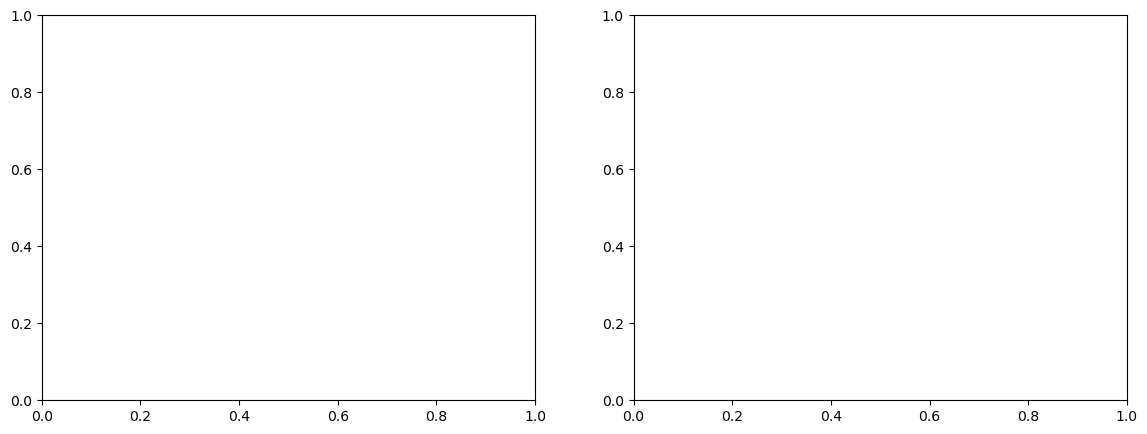

In [79]:
# ---------- VISUALIZATION ----------
print("\n" + "="*50)
print("VISUALIZATION")
print("="*50)

# Plot 1: Cost vs Iterations (first part)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


In [80]:
# Left plot: First 100 iterations
ax1.plot(J_hist[:100])
ax1.set_title("Cost vs. Iteration (First 100 steps)")
ax1.set_ylabel('Cost')
ax1.set_xlabel('Iteration Step')
ax1.grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [81]:
# Right plot: Last 1000 iterations
start = min(1000, len(J_hist) - 1000)
ax2.plot(range(start, len(J_hist)), J_hist[start:])
ax2.set_title("Cost vs. Iteration (End of training)")
ax2.set_ylabel('Cost')
ax2.set_xlabel('Iteration Step')
ax2.grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

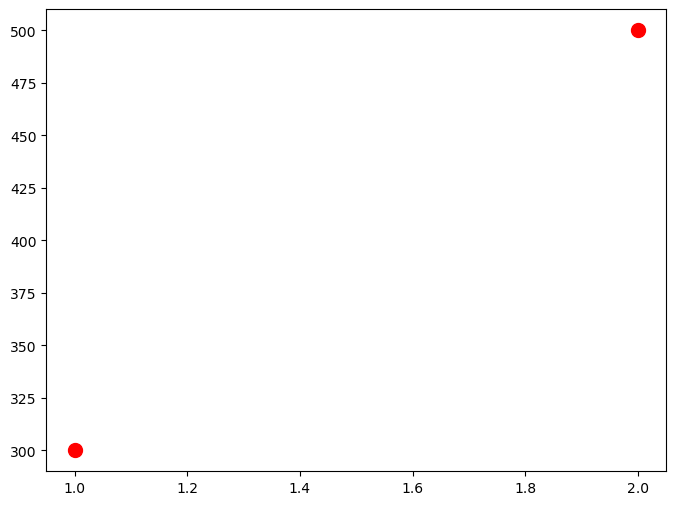

In [82]:
# Plot 2: The final line on the data
fig, ax = plt.subplots(figsize=(8, 6))

# Plot training data
ax.scatter(x_train, y_train, color='red', s=100, label='Training Data', zorder=3)

In [83]:
# Plot the line
x_line = np.linspace(0, 3, 100)
y_line = w_final * x_line + b_final
ax.plot(x_line, y_line, 'b-', label=f'w={w_final:.2f}, b={b_final:.2f}', linewidth=2)

ax.set_xlabel('House Size (1000 sqft)')
ax.set_ylabel('Price (1000 dollars)')
ax.set_title('Linear Regression Result')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n Gradient descent completed successfully!")
print("The model learned: Price = {:.2f} × Size + {:.2f}".format(w_final, b_final))


<Figure size 640x480 with 0 Axes>


 Gradient descent completed successfully!
The model learned: Price = 199.99 × Size + 100.01


Training Data:
x_train = [1. 2.]
y_train = [300. 500.]
Number of training examples: 2

RUNNING GRADIENT DESCENT

Starting values: w=0, b=0
Learning rate: 0.01
Number of iterations: 10000

Iteration    0: Cost 7.93e+04 | dj_dw: -6.500e+02, dj_db: -4.000e+02 | w:  6.500e+00, b:  4.00000e+00
Iteration 1000: Cost 3.41e+00 | dj_dw: -3.712e-01, dj_db:  6.007e-01 | w:  1.949e+02, b:  1.08228e+02
Iteration 2000: Cost 7.93e-01 | dj_dw: -1.789e-01, dj_db:  2.895e-01 | w:  1.975e+02, b:  1.03966e+02
Iteration 3000: Cost 1.84e-01 | dj_dw: -8.625e-02, dj_db:  1.396e-01 | w:  1.988e+02, b:  1.01912e+02
Iteration 4000: Cost 4.28e-02 | dj_dw: -4.158e-02, dj_db:  6.727e-02 | w:  1.994e+02, b:  1.00922e+02
Iteration 5000: Cost 9.95e-03 | dj_dw: -2.004e-02, dj_db:  3.243e-02 | w:  1.997e+02, b:  1.00444e+02
Iteration 6000: Cost 2.31e-03 | dj_dw: -9.660e-03, dj_db:  1.563e-02 | w:  1.999e+02, b:  1.00214e+02
Iteration 7000: Cost 5.37e-04 | dj_dw: -4.657e-03, dj_db:  7.535e-03 | w:  1.999e+02, b:  1.00103e

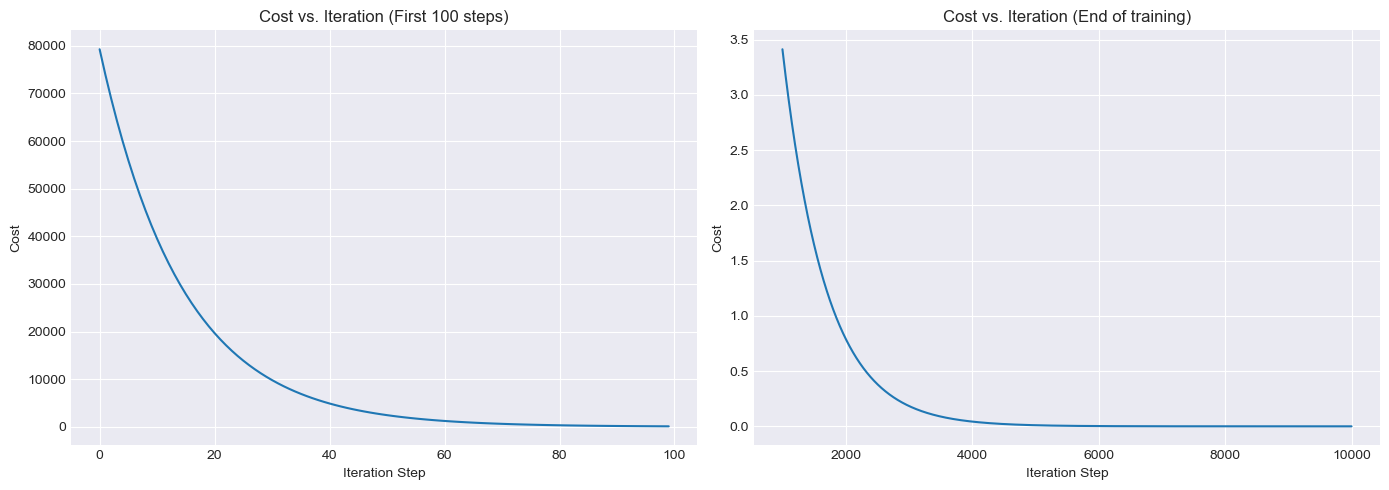

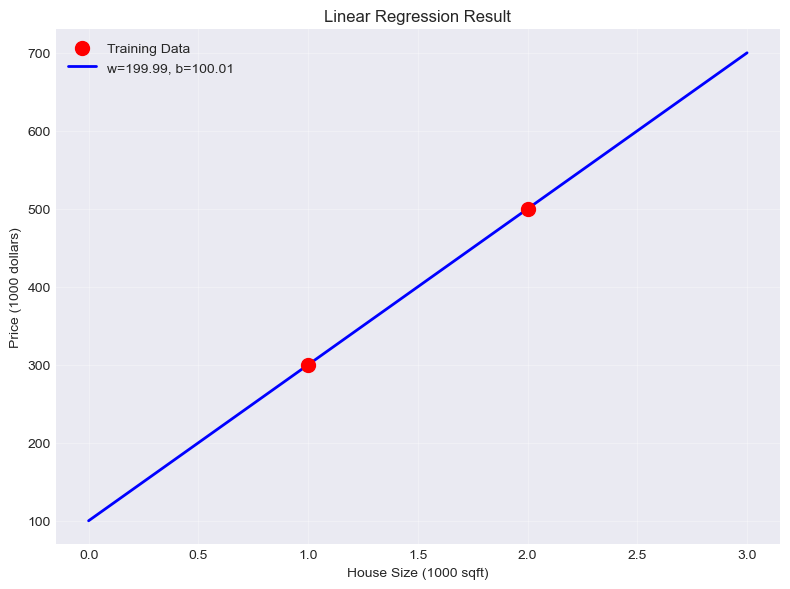


 Gradient descent completed successfully!
The model learned: Price = 199.99 × Size + 100.01


In [ ]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')  

x_train = np.array([1.0, 2.0])     
y_train = np.array([300.0, 500.0]) 
print("Training Data:")
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")
print(f"Number of training examples: {x_train.shape[0]}") # or len(x)

def compute_cost(x, y, w, b):

    m = x.shape[0]              
    cost = 0                    
    
    for i in range(m):
        f_wb = w * x[i] + b  # prediction and y[i] is the target   
        cost = cost + (f_wb - y[i])**2  
    
    total_cost = 1 / (2 * m) * cost  
    return total_cost

def compute_gradient(x, y, w, b):
   
    m = x.shape[0]              
    dj_dw = 0                   
    dj_db = 0                  
    
    for i in range(m):
        f_wb = w * x[i] + b    
        dj_dw_i = (f_wb - y[i]) * x[i]  
        dj_db_i = f_wb - y[i]           
        dj_dw += dj_dw_i        
        dj_db += dj_db_i        
    
    dj_dw = dj_dw / m           
    dj_db = dj_db / m          
    
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  
    J_history = []      
    p_history = []      
    b = b_in           
    w = w_in           
    
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        if i < 100000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])

        # The upcoming code prints every 10% of the total iterations
        if i % math.ceil(num_iters / 10) == 0:
            cost = J_history[-1] if J_history else cost_function(x, y, w, b) # Gets the current cost value to print 
            print(f"Iteration {i:4}: Cost {cost:0.2e} | "
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e} | "
                  f"w: {w: 0.3e}, b: {b: 0.5e}")
            """
                    {i:4} Print i with 4 spaces	" 0", "1000"
                    {cost:0.2e}	Scientific notation with 2 decimals	"4.50e+05"
                    {dj_dw: 0.3e} Scientific notation with 3 decimals	"-6.500e+02"
                    {w: 0.3e} Scientific notation with 3 decimals	" 6.500e+00"
                    {b: 0.5e} Scientific notation with 5 decimals	" 4.00000e+00"
             """

    return w, b, J_history, p_history

print("\n" + "="*50)
print("RUNNING GRADIENT DESCENT")
print("="*50)

w_init = 0
b_init = 0

iterations = 10000
alpha = 1.0e-2  # 0.01

print(f"\nStarting values: w={w_init}, b={b_init}")
print(f"Learning rate: {alpha}")
print(f"Number of iterations: {iterations}\n")

w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, 
    iterations, compute_cost, compute_gradient
)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Final w: {w_final:8.4f}")
print(f"Final b: {b_final:8.4f}")
print(f"Final cost: {J_hist[-1]:0.2e}")

print("\n" + "="*50)
print("VERIFICATION WITH TRAINING DATA")
print("="*50)
print(f"1000 sqft house: {w_final*1.0 + b_final:0.1f} Thousand dollars (Actual: 300.0)")
print(f"2000 sqft house: {w_final*2.0 + b_final:0.1f} Thousand dollars (Actual: 500.0)")

print("\n" + "="*50)
print("PREDICTIONS FOR NEW DATA")
print("="*50)
print(f"1200 sqft house: {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"1500 sqft house: {w_final*1.5 + b_final:0.1f} Thousand dollars")
print(f"1800 sqft house: {w_final*1.8 + b_final:0.1f} Thousand dollars")

print("\n" + "="*50)
print("VISUALIZATION")
print("="*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(J_hist[:100])
ax1.set_title("Cost vs. Iteration (First 100 steps)")
ax1.set_ylabel('Cost')
ax1.set_xlabel('Iteration Step')
ax1.grid(True)

start = min(1000, len(J_hist) - 1000) # Shows iterations 1000 to 10000 (the last 9000 iterations)
ax2.plot(range(start, len(J_hist)), J_hist[start:])
ax2.set_title("Cost vs. Iteration (End of training)")
ax2.set_ylabel('Cost')
ax2.set_xlabel('Iteration Step')
ax2.grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x_train, y_train, color='red', s=100, label='Training Data', zorder=3)

x_line = np.linspace(0, 3, 100)
y_line = w_final * x_line + b_final
ax.plot(x_line, y_line, 'b-', label=f'w={w_final:.2f}, b={b_final:.2f}', linewidth=2)

ax.set_xlabel('House Size (1000 sqft)')
ax.set_ylabel('Price (1000 dollars)')
ax.set_title('Linear Regression Result')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n Gradient descent completed successfully!")
print("The model learned: Price = {:.2f} × Size + {:.2f}".format(w_final, b_final))
